## Drones Automatisation Cluster

In [27]:
import networkx as nx
import matplotlib.pyplot as plt
import itertools
import random
import pickle
import osmnx as ox
import time
import numpy as np
from sklearn.cluster import KMeans
from IPython.display import clear_output
from networkx.algorithms.matching import max_weight_matching

In [28]:
#Animation

import time
from IPython.display import clear_output

In [29]:
def save_graph(G, nom_fichier):
    nom_fichier = nom_fichier.replace(" ", "-")
    with open(nom_fichier, 'wb') as f:
        pickle.dump(G, f, pickle.HIGHEST_PROTOCOL)
    print(f"Graphe du quartier sauvegardé dans : {nom_fichier}")

In [30]:
def fetch_arrondissement(arrondissement):
    quartier = arrondissement + ", Montréal, Québec, Canada"
    G = ox.graph_from_place(quartier, network_type="drive")
    G = ox.distance.add_edge_lengths(G)
    return G

In [31]:
def import_G(filename):
    #filename = "plateau_mont_royal.gpickle"
    
    with open(filename, 'rb') as f:
        G = pickle.load(f).to_undirected()
    return G

In [32]:
def snowize(G, p = 0.5):
    for u, v in G.edges():
        for key in G[u][v]:
            if (random.random() <= p):
                G[u][v][key]['snow'] = 1
            else:
                G[u][v][key]['snow'] = 0
    return G

In [33]:
def eulerize(G):

    G_bis = nx.MultiGraph(G)
    
    for u, v in G.edges():
        for key in G_bis[u][v]:
            G_bis[u][v][key]['snow'] = random.randint(0, 1)
    
    # Identifier les nœuds de degré impair
    odd_nodes = [v for v, d in G_bis.degree() if d % 2 == 1]
    
    # Extraire leurs coordonnées (x, y)
    positions = np.array([[G.nodes[n]['x'], G.nodes[n]['y']] for n in odd_nodes])
    
    k = 130  # nb cluster: + eleve = + rapide, mais - optimal
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(positions)
    
    # Répartir les nœuds dans leurs clusters
    clusters = {}
    for idx, node in enumerate(odd_nodes):
        label = labels[idx]
        clusters.setdefault(label, []).append(node)
    
    G_aug = nx.MultiGraph(G)
    
    for label, nodes in clusters.items():
        if len(nodes) < 2:
            continue
    
        # Générer toutes les paires dans le cluster
        local_pairs = list(itertools.combinations(nodes, 2))
    
        pair_weights = {}
        for u, v in local_pairs:
            try:
                length = nx.dijkstra_path_length(G_bis, u, v, weight='length')
                pair_weights[(u, v)] = length
            except nx.NetworkXNoPath:
                continue
    
        neg_weights = {pair: -w for pair, w in pair_weights.items()}
        matching_graph = nx.Graph([(u, v, {'weight': neg_weights[(u, v)]}) for (u, v) in neg_weights])
        matching = max_weight_matching(matching_graph, maxcardinality=True)
    
        for u, v in matching:
            try:
                path = nx.dijkstra_path(G_bis, u, v, weight='length')
                path_edges = list(zip(path[:-1], path[1:]))
                for edge in path_edges:
                    weight = G_bis[edge[0]][edge[1]][0]['length']
                    G_aug.add_edge(edge[0], edge[1], weight=weight, virtual=True)
            except nx.NetworkXNoPath:
                continue
    
    print("Ce graphe est eulérien :", nx.is_eulerian(G_aug))
    if nx.is_eulerian(G_aug):
        circuit = list(nx.eulerian_circuit(G_aug))

    # Étape de correction : traiter les sommets encore impairs globalement
    remaining_odd_nodes = [v for v, d in G_aug.degree() if d % 2 == 1]
    print(f"{len(remaining_odd_nodes)} sommets impairs restants après clustering")
    
    if len(remaining_odd_nodes) > 1:
        residual_pairs = list(itertools.combinations(remaining_odd_nodes, 2))
    
        residual_weights = {}
        for u, v in residual_pairs:
            try:
                length = nx.dijkstra_path_length(G_bis, u, v, weight='length')
                residual_weights[(u, v)] = length
            except nx.NetworkXNoPath:
                continue
    
        neg_weights = {pair: -w for pair, w in residual_weights.items()}
        residual_graph = nx.Graph([(u, v, {'weight': neg_weights[(u, v)]}) for (u, v) in neg_weights])
        residual_matching = max_weight_matching(residual_graph, maxcardinality=True)
    
        for u, v in residual_matching:
            try:
                path = nx.dijkstra_path(G_bis, u, v, weight='length')
                path_edges = list(zip(path[:-1], path[1:]))
                for edge in path_edges:
                    weight = G_bis[edge[0]][edge[1]][0]['length']
                    G_aug.add_edge(edge[0], edge[1], weight=weight)
            except nx.NetworkXNoPath:
                continue
    return G_aug


def circuit(G_aug):
    return list(nx.eulerian_circuit(G_aug))

In [34]:
def snow_roads(G_aug, G_bis):
    circuit = list(nx.eulerian_circuit(G_aug))
    edges = []
    for i, (u, v) in enumerate(circuit):
        for key in G_bis[u][v]:
            if G_bis[u][v][key]['snow']:
                edges.append((u, v, key))

    return edges

In [59]:
def animation(G_aug, arrondissement, snow_edges):

    pos = {node: (data['x'], data['y']) for node, data in G_aug.nodes(data=True)}
    cir = circuit(G_aug)
    
    def is_valid_edge(u, v, d):
        # Garder les arêtes réelles, ou virtuelles si elles sont courtes
        x1, y1 = pos[u]
        x2, y2 = pos[v]
        return (x1 != x2) and (y1 != y2)

    edges_to_draw = [(u, v) for u, v, d in G_aug.edges(data=True) if is_valid_edge(u, v, d)]
    edges_drawn = []

    for i, edge in enumerate(cir):
        edges_drawn.append(edge)

        clear_output(wait=True)
        plt.figure(figsize=(20, 20))

        nx.draw_networkx_nodes(G_aug, pos, node_color="tab:blue", node_size=0, alpha=0.5)

        nx.draw_networkx_edges(G_aug, pos, edgelist=edges_to_draw, width=0.5, alpha=0.1, edge_color="gray")

        nx.draw_networkx_edges(G_aug, pos, edgelist=edges_drawn, width=2, alpha=0.9, edge_color="tab:red")

        nx.draw_networkx_edges(
        G_aug,
        pos,
        edgelist=snow_edges,
        width=1,
        alpha=0.5,
        edge_color="tab:blue",
    )

        plt.title(f"{arrondissement} - Étape {i+1} / {len(cir)}", fontsize=14)
        plt.axis("off")
        plt.tight_layout()
        plt.show()
        

In [53]:
def show_visited_graph(G_aug, arrondissement, snow_edges):
    # Position geographique reelle
    pos = {node: (data['x'], data['y']) for node, data in G_aug.nodes(data=True)}
    
    circuit = list(nx.eulerian_circuit(G_aug))
        
    clear_output(wait=True)
    plt.figure(figsize=(12, 12))

    options = {"edgecolors": "tab:gray", "node_size": 0.5, "alpha": 0.8}
    nx.draw_networkx_nodes(G_aug, pos, node_color="tab:blue", **options)
    
    nx.draw_networkx_edges(G_aug, pos, width=0.5, alpha=0.2, edge_color="gray")

    nx.draw_networkx_edges(
        G_aug,
        pos,
        edgelist=snow_edges,
        width=1,
        alpha=0.5,
        edge_color="tab:blue",
    )
    
    nx.draw_networkx_edges(
        G_aug,
        pos,
        edgelist=circuit,
        width=2,
        alpha=0.9,
        edge_color="tab:red",
    )

    plt.title(f"{arrondissement}", fontsize=14)
    plt.axis("off")
    plt.tight_layout()
    plt.show()
        

In [37]:
arrondissements = [
    #"Le Plateau-Mont-Royal",
    #"Le Sud-Ouest",
    #"L’Île-Bizard–Sainte-Geneviève",
    #"Mercier–Hochelaga-Maisonneuve",
    #"Montréal-Nord",
    #"Outremont",
    #"Pierrefonds-Roxboro",
    #"Rivière-des-Prairies–Pointe-aux-Trembles",
    #"Rosemont–La Petite-Patrie",
    #"Saint-Laurent",
    #"Saint-Léonard",
    #"anjou",
    "montreal"
    #"outremont",
    #"plateau_mont_royal",
    #"riviere-des-prairies-pointe-aux-trembles",
    #"verdun"
    ]

In [38]:
def gpickle(arrondissements):
    for arrondissement in arrondissements:
        G = fetch_arrondissement(arrondissement)
        save_graph(G,arrondissement)

#gpickle(arrondissements)

In [39]:
def euler_save(arrondissements):
    for arrondissement in arrondissements:
        start = time.time()    
        G = import_G("../database/maps/" + arrondissement.replace(" ", "-") + ".gpickle")
        G_aug = eulerize(G)
        #circuit(G_aug)
         
        save_graph(G_aug, "../database/eulerized_maps/" + arrondissement + "_aug.gpickle")
        end = time.time()

        print(str(end - start) + " secondes")
        
euler_save(arrondissements)

Ce graphe est eulérien : False
64 sommets impairs restants après clustering
Graphe du quartier sauvegardé dans : ../database/eulerized_maps/montreal_aug.gpickle
1279.6115849018097 secondes


In [42]:
def animation_import(arrondissement):
    #G_aug = version euleurisee de G
    #print("gpickle/G_aug/" + arrondissement.replace(" ", "-") + "_aug.gpickle")
    G_aug = import_G("../database/eulerized_maps/" + arrondissement.replace(" ", "-") + "_aug.gpickle")
    G = import_G("../database/maps/" + arrondissement.replace(" ", "-") + ".gpickle")
    G = snowize(G)
    #G_bis = copie de G en Multigraph
    G_bis = nx.MultiGraph(G)

    snow_edges = snow_roads(G_aug, G_bis)
    #show_visited_graph(G_aug, arrondissement, snow_edges)
    animation(G_aug, arrondissement, snow_edges)

KeyboardInterrupt: 

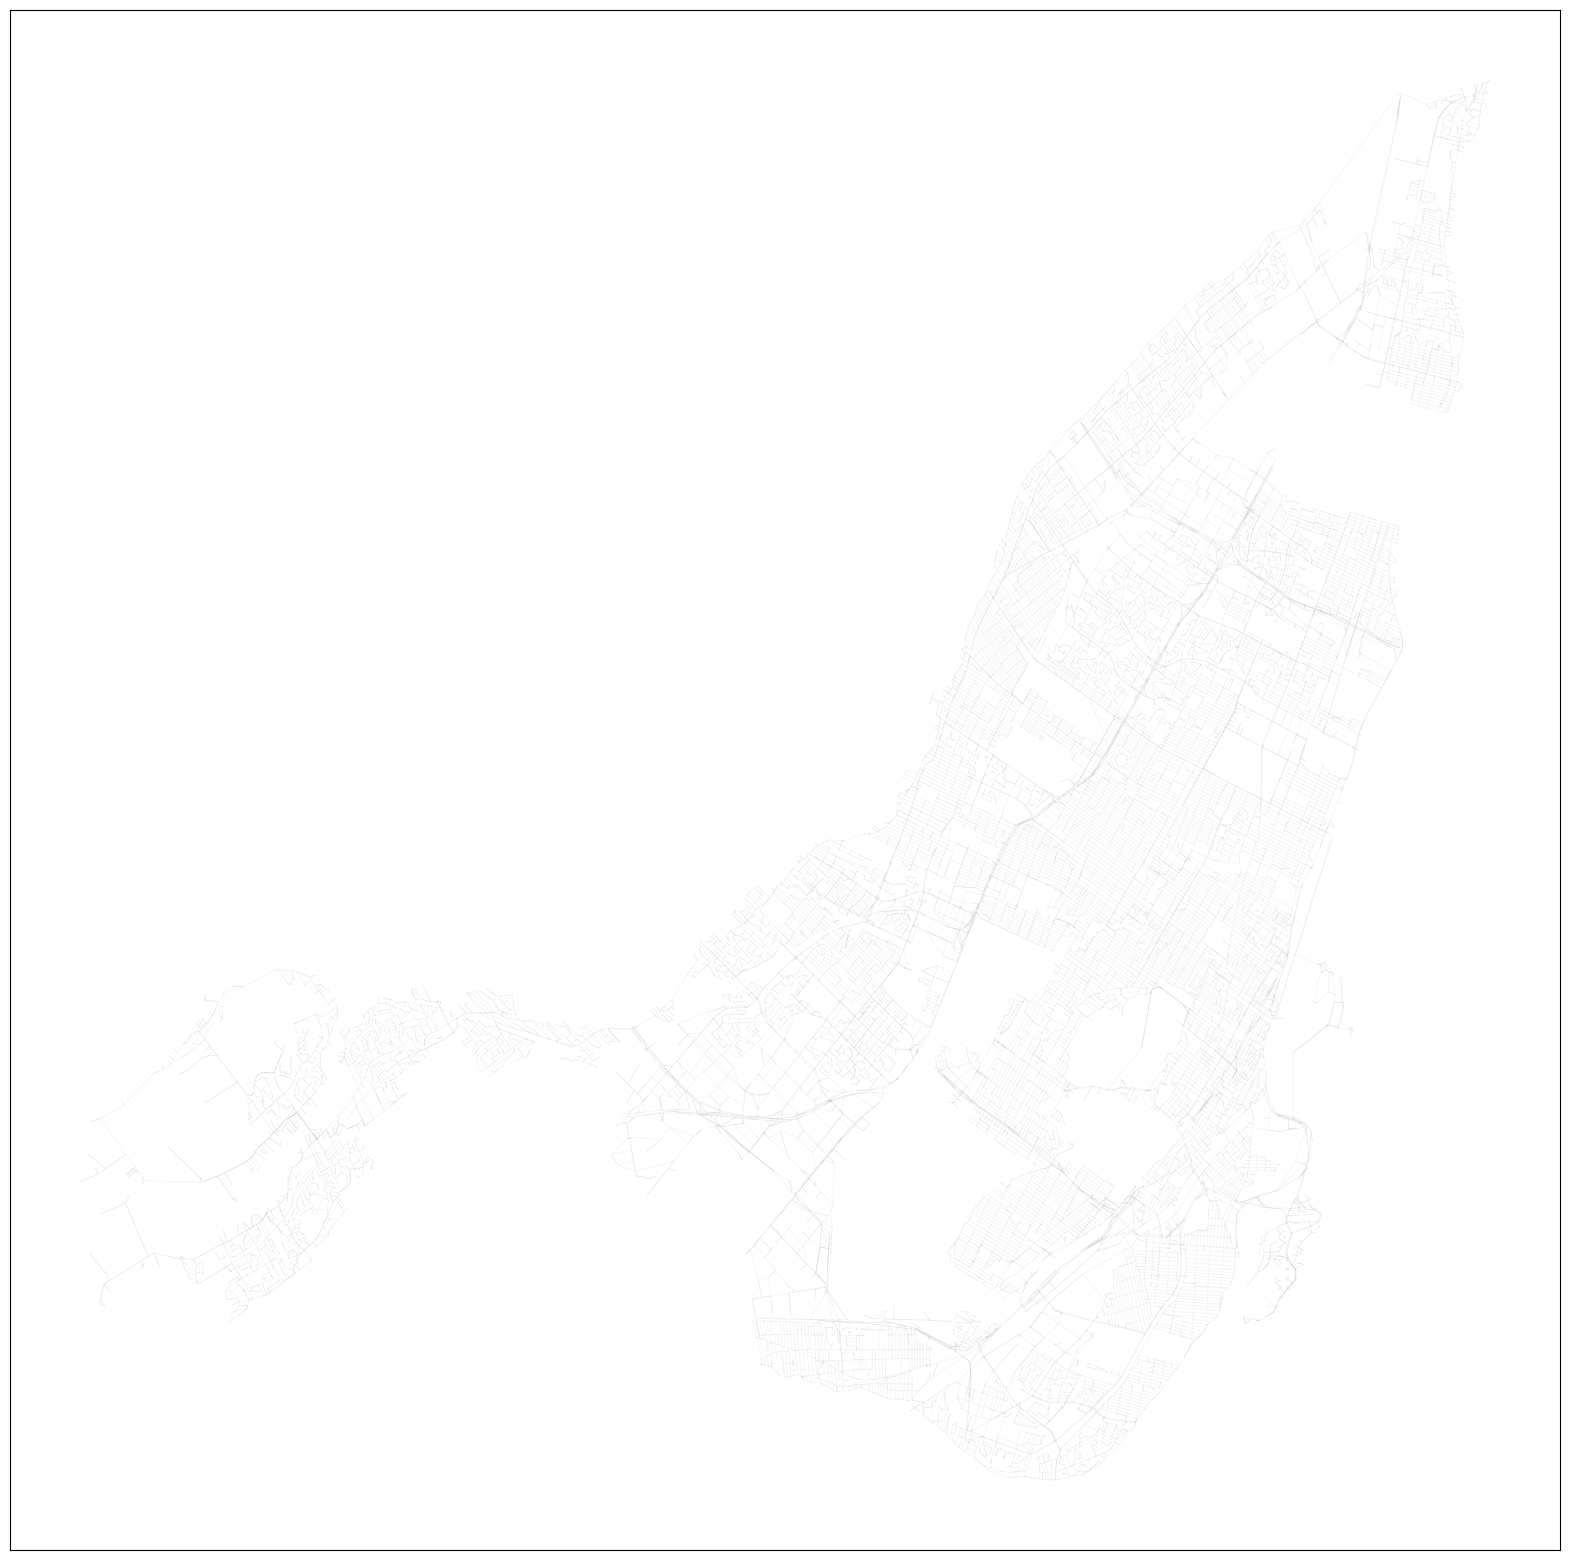

In [60]:
animation_import("montreal")